# RAG Cache with LangGraph (PDF + ChromaDB + Redis Semantic Cache)

A Retrieval-Augmented Generation pipeline orchestrated with **LangGraph**, with a
**Redis semantic cache** sitting in front of it. Knowledge comes from a **PDF**
indexed into **ChromaDB**.



* **Normalize** (new): the raw query is rewritten by the LLM into a canonical,
  intent-preserving form before it ever touches the cache.  Paraphrases,
  abbreviations, and stylistic variations collapse to the same string, so
  semantically equivalent queries always hit.
* **Cache hit** (Redis) -> skip retrieval *and* the LLM, return the cached answer instantly.
* **Cache miss** -> retrieve relevant chunks from **ChromaDB** (built from your PDF),
  generate an answer with the LLM, then store  back in the
  Redis semantic cache so semantically similar future queries hit.

Two embedding spaces are at play, and that's intentional:
- **Redis semantic cache** uses  for query-similarity lookups.
- **ChromaDB** uses its own embedding function for document retrieval.


## 0. Install dependencies



In [15]:
import sys, subprocess

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "chromadb", "pypdf"],
    check=True,
)
print("chromadb + pypdf installed")

chromadb + pypdf installed


In [1]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

## 1. Connect to Redis

In [2]:
import os
import redis

REDIS_URL = os.getenv("REDIS_URL")

try:
    r = redis.Redis.from_url(REDIS_URL)
    r.ping()
    print("Redis is running and accessible")
except redis.ConnectionError:
    print("Cannot connect to Redis")
    raise

Redis is running and accessible


## 2. Redis Semantic Cache

The cache maps a user **query -> answer**. We use the cache-optimized embedding model
[`redis/langcache-embed-v1`](https://huggingface.co/redis/langcache-embed-v1), with
`EmbeddingsCache` to avoid re-embedding identical text.

In [18]:
from redisvl.utils.vectorize import HFTextVectorizer
from redisvl.extensions.cache.embeddings import EmbeddingsCache
from redisvl.extensions.cache.llm import SemanticCache

langcache_embed = HFTextVectorizer(
    model="redis/langcache-embed-v1",
    cache=EmbeddingsCache(redis_client=r, ttl=3600),
)

cache = SemanticCache(
    name="rag-cache-v2",
    vectorizer=langcache_embed,
    redis_client=r,
    distance_threshold=0.35,  # raised from 0.2 -> wider net for paraphrases
                               # primary guard is the LLM normalizer (see Section 5)
)

cache.set_ttl(86400)  # keep cached answers fresh for 24h
print("Semantic cache ready")


10:28:40 sentence_transformers.SentenceTransformer INFO   Use pytorch device_name: cpu


10:28:40 sentence_transformers.SentenceTransformer INFO   Load pretrained SentenceTransformer: redis/langcache-embed-v1
Semantic cache ready


## 3. Build the knowledge base from a PDF (ChromaDB)

Set `PDF_PATH` to your document. We extract text with `pypdf`, split it into
overlapping chunks, and index those chunks in a persistent ChromaDB collection.
ChromaDB embeds the chunks with its default embedding function (a bundled
sentence-transformers MiniLM model) — no extra config needed.

In [4]:
PDF_PATH = "/home/harsh/Desktop/sementic-caching/utils/data/Policy Artificial Intelligence.docx (1).pdf"

assert os.path.exists(PDF_PATH), (
    f"PDF not found at {PDF_PATH!r}. Set PDF_PATH to a real file and re-run this cell."
)

from pypdf import PdfReader

reader = PdfReader(PDF_PATH)
pages = [page.extract_text() or "" for page in reader.pages]
full_text = "\n".join(pages)

print(f"Loaded {len(pages)} pages, {len(full_text):,} characters from {os.path.basename(PDF_PATH)}")

Loaded 7 pages, 10,801 characters from Policy Artificial Intelligence.docx (1).pdf


In [5]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=120,
)
chunks = splitter.split_text(full_text)
chunks = [c for c in chunks if c.strip()]

print(f"Split into {len(chunks)} chunks")

Split into 17 chunks


In [6]:
import chromadb

CHROMA_PATH = "/home/harsh/Desktop/sementic-caching/chroma_db"
COLLECTION_NAME = "pdf-rag"

chroma_client = chromadb.PersistentClient(path=CHROMA_PATH)

# Rebuild the collection from scratch 
try:
    chroma_client.delete_collection(COLLECTION_NAME)
except Exception:
    pass

collection = chroma_client.create_collection(COLLECTION_NAME)
collection.add(
    documents=chunks,
    ids=[f"chunk-{i}" for i in range(len(chunks))],
)

print(f"Indexed {collection.count()} chunks into ChromaDB collection '{COLLECTION_NAME}'")

Indexed 17 chunks into ChromaDB collection 'pdf-rag'


## 4. The LLM

In [7]:
from utils.cache.config import load_openai_key
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

load_openai_key()

MODEL_NAME = "gpt-4o-mini"

llm = ChatOpenAI(
    model=MODEL_NAME,
    temperature=0.1,
    max_tokens=300,
)

> OpenAI API key is already loaded in the environment


## 5. Define the LangGraph

**State** carried through the graph:

| field             | meaning                                                        |
|-------------------|----------------------------------------------------------------|
|            | the original user question (never mutated)                     |
|  |      — normalized form used for cache lookup & storage      |
|        | whether  found a semantic match                   |
|         | vector distance of the cache hit (for inspection)              |
|          | chunks returned by  (from ChromaDB)                  |
|           | the final answer (from cache or freshly generated)             |

### The normalization strategy

Before every cache lookup, the raw query passes through , a one-shot LLM
call that rewrites it into a canonical English sentence preserving only the core
information need.  This collapses the long tail of phrasings:



The canonical form is stored as the cache key, so every future paraphrase — once
normalized — hits the same entry.

The  is raised from 0.2 → 0.35 as a secondary safety net for
cases where normalization still produces minor lexical variation.


In [8]:
from typing import TypedDict, List, Optional
from langgraph.graph import StateGraph, START, END

TOP_K = 4


class RAGState(TypedDict):
    query: str                    # original user input (never mutated)
    canonical_query: str          # normalized form used for cache lookup & storage
    cache_hit: bool
    distance: float
    context: List[str]
    answer: str


In [10]:
# ---------------------------------------------------------------------------
# Query normalizer prompt
# ---------------------------------------------------------------------------

NORMALIZE_SYSTEM = """
You are a query normalizer for a RAG system.

Your job: rewrite the user's question into a single, canonical English sentence
that captures the core information need — regardless of phrasing, tone, or style.

Rules:
- Preserve the exact intent; do NOT add, remove, or assume information.
- Output ONLY the rewritten question. No preamble, no explanation.
- Keep it concise (one sentence).

Examples
--------
Input: "What's this doc about?"
Output: What is the main topic of this document?

Input: "Can u summarize what the document covers"
Output: What is the main topic of this document?

Input: "Give me a brief overview of the key ideas"
Output: What is the main topic of this document?

Input: "Who are the stakeholders mentioned in the policy?"
Output: Who are the stakeholders mentioned in the policy?
"""


def _normalize_query(raw_query: str) -> str:
    """Return canonical form of raw_query using the LLM."""

    prompt = f"""{NORMALIZE_SYSTEM}

Input: {raw_query}
Output:"""

    response = llm.invoke([
        HumanMessage(content=prompt)
    ])

    return response.content.strip()


# ---------------------------------------------------------------------------
# Nodes
# ---------------------------------------------------------------------------

def normalize(state: RAGState) -> dict:
    """
    Rewrite the raw query into a canonical form before touching the cache.

    Semantically equivalent questions (paraphrases, abbreviations, different
    phrasing styles) collapse to the same canonical string so they all hit the
    same cache entry.
    """

    canonical = _normalize_query(state["query"])

    print(
        f"  Normalized: {state['query']!r} -> {canonical!r}"
    )

    return {
        "canonical_query": canonical
    }


def cache_check(state: RAGState) -> dict:
    """
    Look up the canonical query in the Redis semantic cache.
    """

    hit = cache.check(state["canonical_query"])

    if hit:
        return {
            "cache_hit": True,
            "answer": hit[0]["response"],
            "distance": hit[0]["vector_distance"],
        }

    return {
        "cache_hit": False
    }


def route(state: RAGState) -> str:
    """
    Conditional edge:
    - 'hit'  -> short-circuit
    - 'miss' -> run retrieval + generation
    """

    return "hit" if state["cache_hit"] else "miss"


def hit(state: RAGState) -> dict:
    """
    Cache hit - answer already exists.
    """

    print(
        f"  CACHE HIT (distance {state['distance']:.3f}) "
        f"- skipped retrieval + LLM"
    )

    return {}


def retrieve(state: RAGState) -> dict:
    """
    Cache miss - retrieve top-k chunks from ChromaDB using canonical query.
    """

    print("  CACHE MISS - retrieving from ChromaDB...")

    results = collection.query(
        query_texts=[state["canonical_query"]],
        n_results=TOP_K
    )

    docs = results["documents"][0]

    print(f"  retrieved {len(docs)} chunks")

    return {
        "context": docs
    }


def generate(state: RAGState) -> dict:
    """
    Generate an answer grounded in the retrieved chunks.
    """

    context = "\n\n---\n\n".join(state["context"])

    prompt = f"""
Answer the question using ONLY the context below.

Be concise and professional.

If the context does not contain the answer, say:
"I don't know based on the provided document."

Context:
{context}

Question:
{state['canonical_query']}

Answer:
"""

    response = llm.invoke([
        HumanMessage(content=prompt)
    ])

    return {
        "answer": response.content.strip()
    }


def add_cache(state: RAGState) -> dict:
    """
    Store the generated answer under the canonical query.

    Using the canonical form as the cache key means all future paraphrases
    of the same intent will match this entry.
    """

    cache.store(
        prompt=state["canonical_query"],
        response=state["answer"]
    )

    print(
        "  Stored answer in Redis semantic cache "
        "(key = canonical query)"
    )

    return {}

In [ ]:
# Wire the graph ---------------------------------------------------------------
builder = StateGraph(RAGState)

builder.add_node("normalize", normalize)      
builder.add_node("cache_check", cache_check)
builder.add_node("hit", hit)
builder.add_node("retrieve", retrieve)
builder.add_node("generate", generate)
builder.add_node("add_cache", add_cache)

builder.add_edge(START, "normalize")           # query -> normalize first
builder.add_edge("normalize", "cache_check")   # then check cache with canonical form
builder.add_conditional_edges(
    "cache_check",
    route,
    {"hit": "hit", "miss": "retrieve"},
)
builder.add_edge("hit", END)
builder.add_edge("retrieve", "generate")
builder.add_edge("generate", "add_cache")
builder.add_edge("add_cache", END)

app = builder.compile()


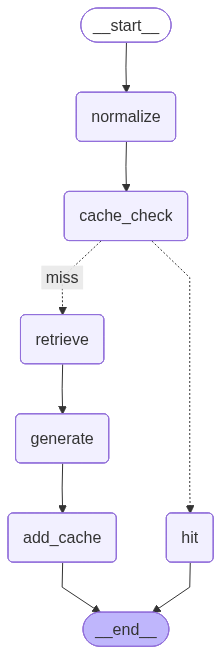

In [12]:
# Visualize the execution graph
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

## 6. Test


In [13]:
def ask(query: str) -> dict:
    print(f"Q: {query}")
    result = app.invoke({"query": query})
    source = "CACHE" if result["cache_hit"] else "RAG (retrieve + generate)"
    print(f"  Source: {source}")
    print(f"  A: {result['answer']}\n")
    return result

In [19]:
# First call: cache MISS -> normalize -> retrieve -> generate -> add_cache
_ = ask("What is this document about?")

# These are semantically identical but worded differently.
# All normalize to the same canonical form -> CACHE HIT
_ = ask("Can you summarize what this document covers?")
_ = ask("Give me a brief overview of this document")
_ = ask("What's in this doc?")


Q: What is this document about?
10:29:11 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  Normalized: 'What is this document about?' -> 'What is the main topic of this document?'
  CACHE MISS - retrieving from ChromaDB...
  retrieved 4 chunks
10:29:13 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  Stored answer in Redis semantic cache (key = canonical query)
  Source: RAG (retrieve + generate)
  A: The main topic of this document is the AIMS Policy related to Artificial Intelligence.

Q: Can you summarize what this document covers?
10:29:14 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  Normalized: 'Can you summarize what this document covers?' -> 'What is the main topic of this document?'
  CACHE HIT (distance 0.000) - skipped retrieval + LLM
  Source: CACHE
  A: The main topic of this document is the AIMS Policy related to Artificial Intelligen

In [15]:
# Stress-test the normalizer across very different phrasings of the same intent.
# Only the first query in each group should MISS; the rest should HIT.
test_groups = [
    # Group 1 - document overview
    [
        "What are the main ideas covered in this document?",
        "Can you give me a summary?",
        "TL;DR of the doc?",
        "Explain what this file is about",
    ],
]

for group in test_groups:
    print("=" * 60)
    for q in group:
        ask(q)
    print()


Q: What are the main ideas covered in this document?
10:22:23 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  Normalized: 'What are the main ideas covered in this document?' -> 'What are the main ideas covered in this document?'
  CACHE HIT (distance 0.119) - skipped retrieval + LLM
  Source: CACHE
  A: The document outlines principles for the ethical use of Artificial Intelligence, emphasizing transparency, fairness, accountability, safety and security, and compliance with laws and regulations. It also describes the establishment and maintenance of an Artificial Intelligence Management System (AIMS) to ensure continual improvement and effective governance of AI practices.

Q: Can you give me a summary?
10:22:24 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  Normalized: 'Can you give me a summary?' -> 'What is the summary of the document?'
  CACHE HIT (distance 0.149) - skipped retrieval + LL

## 7. Debug helper — inspect cache entries

Use this to verify what canonical forms are being stored and their distances.


In [17]:
def inspect_cache(query: str):
    """Show the canonical form and cache check result for a raw query."""
    canonical = _normalize_query(query)
    hit = cache.check(canonical)
    print(f"Raw:       {query!r}")
    print(f"Canonical: {canonical!r}")
    if hit:
        print(f"Cache HIT  (distance={hit[0]['vector_distance']:.4f})")
        print(f"Cached answer: {hit[0]['response'][:120]}...")
    else:
        print("Cache MISS")
    print()

# Example — run after ask() to verify
inspect_cache("What is this file talking about?")
inspect_cache("Summarize the document briefly")


10:22:48 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Raw:       'What is this file talking about?'
Canonical: 'What is the main topic of this file?'
Cache HIT  (distance=0.2947)
Cached answer: The document outlines principles for the ethical use of Artificial Intelligence, emphasizing transparency, fairness, acc...

10:22:49 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Raw:       'Summarize the document briefly'
Canonical: 'What is the main topic of this document?'
Cache HIT  (distance=0.2069)
Cached answer: The document outlines principles for the ethical use of Artificial Intelligence, emphasizing transparency, fairness, acc...

